# Magnitude-cut comparison: per-event analysis

Loads results from `SDS_bilby_maglim.py` for **both** silver and golden sirens.
Sections 1–7 plot the type selected by `SIREN_TYPE` (set in the first cell).
The fractional-width-growth plot (section 7's last figure) and section 8 overlay
both types for direct comparison.


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Configuration ────────────────────────────────────────────────────────────
# Both siren types are loaded; SIREN_TYPE selects which one drives sections 1-7
# (per-event/per-cut plots). The last two cells overlay both types.
SIREN_TYPE   = "silver"            # "silver" or "golden"  — drives sections 1-7
SIREN_TYPES  = ["silver", "golden"]
STUDY_ROOTS  = {s: f"maglim_study_{s}" for s in SIREN_TYPES}
STUDY_ROOT   = STUDY_ROOTS[SIREN_TYPE]   # alias for sections 1-7

APP_MAG_LIMITS  = [19.5, 21.5, 23.5]
COLORS          = ["C0", "C1", "C2"]                     # one per mag-cut
SIREN_COLORS    = {"silver": "C0", "golden": "C3"}       # silver/golden overlay
SIREN_MARKERS   = {"silver": "o",  "golden": "s"}
SIREN_LINESTYLE = {"silver": "-",  "golden": "--"}
H0_TRUE         = 67.74

print("Siren roots:")
for s, root in STUDY_ROOTS.items():
    print(f"  {s:<6s} -> {os.path.abspath(root)}")
print(f"\nActive SIREN_TYPE (sections 1-7): {SIREN_TYPE}")


Siren roots:
  silver -> /hildafs/projects/phy220048p/share/gwbench_dark_siren/golden-silver-dark-sirens/maglim_study_silver
  golden -> /hildafs/projects/phy220048p/share/gwbench_dark_siren/golden-silver-dark-sirens/maglim_study_golden

Active SIREN_TYPE (sections 1-7): silver


In [29]:
# ── Load per-event stats for BOTH siren types and each mag limit ─────────────
# stats_all[siren_type][mag_limit] -> DataFrame
# stats is aliased to stats_all[SIREN_TYPE] so sections 1-7 keep working.
stats_all = {s: {} for s in SIREN_TYPES}
for s in SIREN_TYPES:
    for m in APP_MAG_LIMITS:
        csv_path = os.path.join(STUDY_ROOTS[s], f"mlim_{m}", "per_event_stats.csv")
        if not os.path.exists(csv_path):
            print(f"  [missing] {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        df = df[~df.get("skipped", pd.Series(False, index=df.index))]
        stats_all[s][m] = df.reset_index(drop=True)
        print(f"  {s:<6s} mlim={m}: {len(df)} events loaded")

stats = stats_all[SIREN_TYPE]   # active-type alias

# Detect column format from the active type (assumed consistent across types).
sample_df  = next(iter(stats.values()))
NEW_FORMAT = "abs_mag_limit" in sample_df.columns
MLIM_COL   = "abs_mag_limit" if NEW_FORMAT else "mag_limit"
print(f"\nColumn format: {'new (abs_mag_limit)' if NEW_FORMAT else 'old (mag_limit / app mag direct)'}")


  silver mlim=19.5: 499 events loaded
  silver mlim=21.5: 499 events loaded
  silver mlim=23.5: 499 events loaded
  golden mlim=19.5: 99 events loaded
  golden mlim=21.5: 99 events loaded
  golden mlim=23.5: 99 events loaded

Column format: new (abs_mag_limit)


## 1  Absolute magnitude limits per event

Each apparent threshold maps to a different absolute depth at each event's distance.
Shallower apparent limit → brighter-only absolute cut at the same redshift.

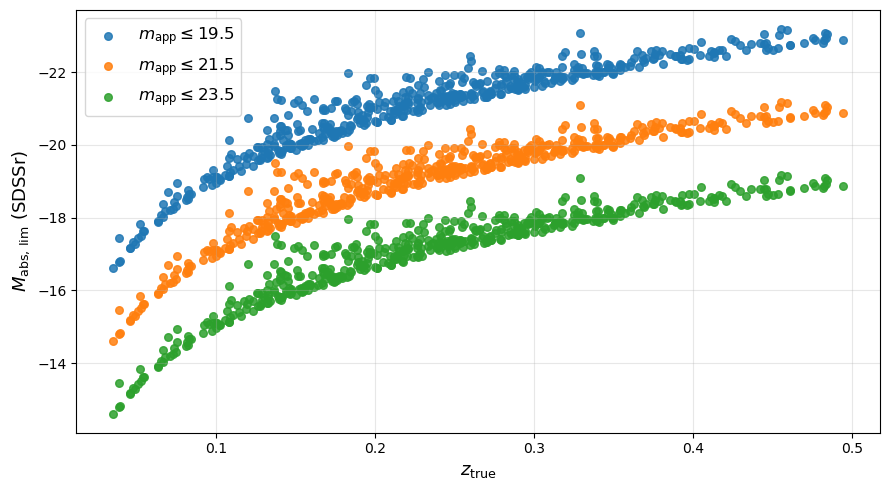

In [30]:
if NEW_FORMAT:
    fig, ax = plt.subplots(figsize=(9, 5))
    for m, color in zip(APP_MAG_LIMITS, COLORS):
        df = stats[m]
        ax.scatter(df['z_true'], df['abs_mag_limit'], color=color, s=30,
                   label=rf"$m_\mathrm{{app}}\leq{m}$", alpha=0.85)
    ax.set_xlabel(r"$z_\mathrm{true}$", fontsize=13)
    ax.set_ylabel(r"$M_\mathrm{abs,\,lim}$ (SDSSr)", fontsize=13)
    ax.legend(fontsize=12)
    ax.invert_yaxis()   # brighter (more negative) at top
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(STUDY_ROOT + "abs_mag_limit_vs_z.png", dpi=300)
    plt.show()
else:
    print("abs_mag_limit column not present — run with the updated SDS_bilby_maglim.py first.")

## 2  Fraction of CI galaxies surviving the cut

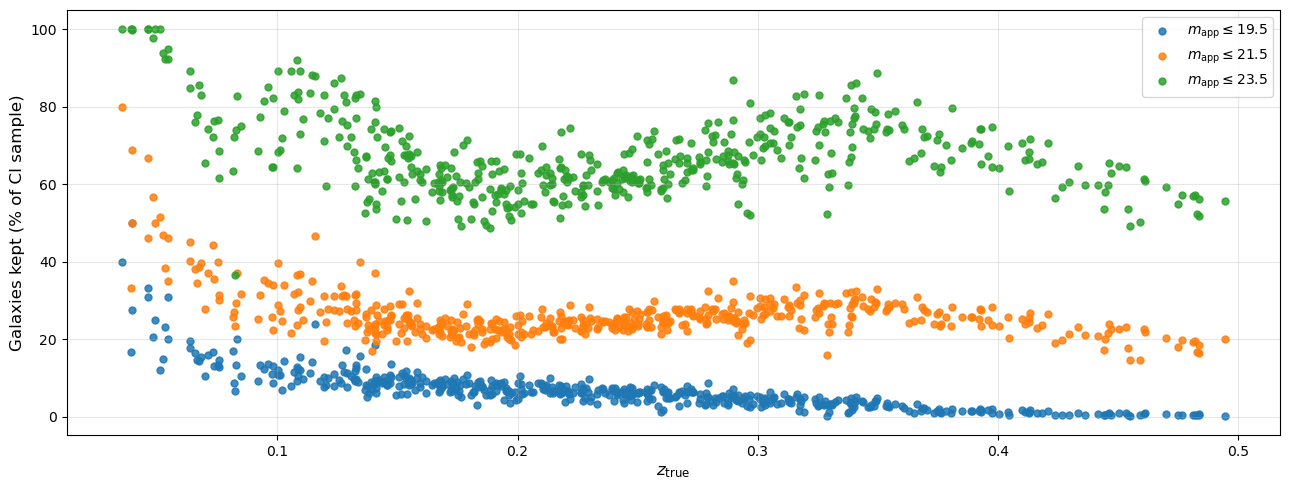

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))

for m, color in zip(APP_MAG_LIMITS, COLORS):
    df = stats[m]
    z_col = 'z_true' if 'z_true' in df.columns else 'z'
    ax.scatter(df[z_col], df['frac_kept'] * 100, color=color, s=25, alpha=0.85,
               label=rf"$m_\mathrm{{app}}\leq{m}$")
ax.set_xlabel(r"$z_\mathrm{true}$", fontsize=12)
ax.set_ylabel("Galaxies kept (% of CI sample)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("completeness_vs_z_DL.png", dpi=300)
plt.show()

## 3  Host galaxy survival

## 4  Per-event H0 posteriors across the three cuts

One panel per event. Each panel shows the H0 posterior for all three absolute-mag limits.

In [14]:
# Load H0 likelihoods for BOTH siren types.
# npz_data_all[siren_type][mag_limit] -> NpzFile
# npz_data is aliased to npz_data_all[SIREN_TYPE].
npz_data_all = {s: {} for s in SIREN_TYPES}
for s in SIREN_TYPES:
    for m in APP_MAG_LIMITS:
        path = os.path.join(STUDY_ROOTS[s], f"mlim_{m}", "H0_likelihoods.npz")
        if os.path.exists(path):
            npz_data_all[s][m] = np.load(path)
        else:
            print(f"  [missing] {path}")

npz_data = npz_data_all[SIREN_TYPE]   # active-type alias
H0_GRID  = npz_data[APP_MAG_LIMITS[0]]["H0_grid"]

# Per-type event-key lists and an active-type alias.
all_event_keys_all = {}
for s in SIREN_TYPES:
    all_event_keys_all[s] = sorted(
        set().union(*[
            {k for k in npz.files if k.startswith("event_")}
            for npz in npz_data_all[s].values()
        ]),
        key=lambda k: int(k.split("_")[1])
    )
    print(f"  {s:<6s}: {len(all_event_keys_all[s])} events with H0 posteriors")

all_event_keys = all_event_keys_all[SIREN_TYPE]


  silver: 499 events with H0 posteriors
  golden: 98 events with H0 posteriors


In [16]:
# Build per-event metadata lookup for BOTH siren types.
# event_meta_all[siren_type][event_key][f"<field>_{m}"] -> value
# event_meta is aliased to event_meta_all[SIREN_TYPE] for use by the plot below
# and later cells.
sample_df = next(iter(stats.values()))
z_col  = "z_true"  if "z_true"  in sample_df.columns else "z"
DL_col = "DL_true" if "DL_true" in sample_df.columns else "DL"

event_meta_all = {s: {} for s in SIREN_TYPES}
for s in SIREN_TYPES:
    em = event_meta_all[s]
    for m, df in stats_all[s].items():
        for _, row in df.iterrows():
            key = f"event_{int(row['inj_num'])}"
            if key not in em:
                em[key] = {}
            em[key][f"z_{m}"]    = row.get(z_col, np.nan)
            em[key][f"DL_{m}"]   = row.get(DL_col, np.nan)
            em[key][f"frac_{m}"] = row.get("frac_kept", np.nan)
            em[key][f"Mlim_{m}"] = row.get("abs_mag_limit", np.nan)
            em[key][f"host_{m}"] = row.get("host_survives_cut", False)
            em[key][f"ncut_{m}"] = row.get("n_after_cut", 0)
    print(f"  {s:<6s}: event_meta built for {len(em)} events")

event_meta = event_meta_all[SIREN_TYPE]   # active-type alias


  silver: event_meta built for 499 events
  golden: event_meta built for 99 events


In [ ]:
# Per-event H0 posterior grid plot — SLOW for 500 events.
# Skip this cell if you only need the downstream analysis; event_meta is already built above.
n_events = len(all_event_keys)
ncols    = 4
nrows    = int(np.ceil(n_events / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows),
                         sharey=False, squeeze=False)

for idx, ekey in enumerate(all_event_keys):
    r, c  = divmod(idx, ncols)
    ax    = axes[r][c]
    meta  = event_meta.get(ekey, {})
    inj_n = int(ekey.split('_')[1])

    z_ev  = meta.get(f'z_{APP_MAG_LIMITS[0]}', np.nan)
    DL_ev = meta.get(f'DL_{APP_MAG_LIMITS[0]}', np.nan)

    for m, color in zip(APP_MAG_LIMITS, COLORS):
        if m not in npz_data or ekey not in npz_data[m]:
            continue
        post   = npz_data[m][ekey]
        Mlim   = meta.get(f'Mlim_{m}', np.nan)
        ncut   = int(meta.get(f'ncut_{m}', 0))
        host_s = bool(meta.get(f'host_{m}', False))

        lbl = rf"$m\leq{m}$"
        if NEW_FORMAT and not np.isnan(Mlim):
            lbl += rf" ($M\leq{Mlim:.1f}$, n={ncut})"
        else:
            lbl += f" (n={ncut})"
        ls = "-" if host_s else "--"
        ax.plot(H0_GRID, post, color=color, lw=1.8, ls=ls, label=lbl)

    ax.axvline(H0_TRUE, color='gray', ls=':', lw=1)
    ax.set_title(
        f"inj_{inj_n}  |  z={z_ev:.3f}  DL={DL_ev:.0f} Mpc",
        fontsize=9
    )
    ax.set_xlabel(r"$H_0$", fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

# Hide unused panels
for idx in range(n_events, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

# Legend for line style
custom_lines = [
    Line2D([0], [0], color='k', lw=1.5, ls='-',  label='host survives cut'),
    Line2D([0], [0], color='k', lw=1.5, ls='--', label='host cut out'),
]
fig.legend(handles=custom_lines, loc='lower right', fontsize=10, framealpha=0.9)

fig.suptitle(
    f"Per-event H0 posteriors: volume-limited cut comparison ({SIREN_TYPE} sirens)\n"
    rf"Solid = host survives cut. Cut: $M_{{\rm abs}} \leq m_{{\rm app}} - \mu(D_L)$.",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(STUDY_ROOT, "per_event_H0_comparison.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved per_event_H0_comparison.png")


KeyboardInterrupt: 

## 5  Summary table

In [17]:
rows = []
for ekey in all_event_keys:
    inj_n = int(ekey.split('_')[1])
    meta  = event_meta.get(ekey, {})
    row   = {'inj_num': inj_n,
             'z':    meta.get(f'z_{APP_MAG_LIMITS[0]}',  np.nan),
             'DL':   meta.get(f'DL_{APP_MAG_LIMITS[0]}', np.nan)}
    for m in APP_MAG_LIMITS:
        row[f'M_lim_{m}']   = meta.get(f'Mlim_{m}',  np.nan)
        row[f'n_kept_{m}']  = meta.get(f'ncut_{m}',  np.nan)
        row[f'frac_{m}']    = meta.get(f'frac_{m}',  np.nan)
        row[f'host_{m}']    = meta.get(f'host_{m}',  False)
    rows.append(row)

summary = pd.DataFrame(rows)




## 7  Statistical comparison of per-event H0 posterior widths

For each event, measure the H0 posterior width under each magnitude cut (68% CI width and std).
Paired tests across events quantify whether deeper cuts systematically tighten the posterior.

Per-cut posterior-width summary:
 mag_limit  n_events  w68_mean  w68_median  w68_std  std_mean  std_median
    19.500       499    11.716      12.763    2.763     5.188       5.525
    21.500       499    11.845      12.870    2.634     5.246       5.561
    23.500       499    11.894      12.886    2.560     5.265       5.566

Paired tests on 68% CI width (Δ = w68[stricter] − w68[looser]):
Positive Δ ⇒ stricter (smaller m_lim) cut gives wider posterior.

  m≤19.5 vs m≤21.5  (n=499):
     mean Δ = -0.129   median Δ = -0.047   std Δ = 0.736
     paired t-test : t=-3.921,  p=0.0001
     Wilcoxon      : W=47655.0,   p=4.93e-06
  m≤21.5 vs m≤23.5  (n=499):
     mean Δ = -0.049   median Δ = -0.009   std Δ = 0.665
     paired t-test : t=-1.648,  p=0.1
     Wilcoxon      : W=56121.0,   p=0.0523
  m≤19.5 vs m≤23.5  (n=499):
     mean Δ = -0.178   median Δ = -0.062   std Δ = 1.009
     paired t-test : t=-3.943,  p=9.2e-05
     Wilcoxon      : W=45650.0,   p=2.1e-07


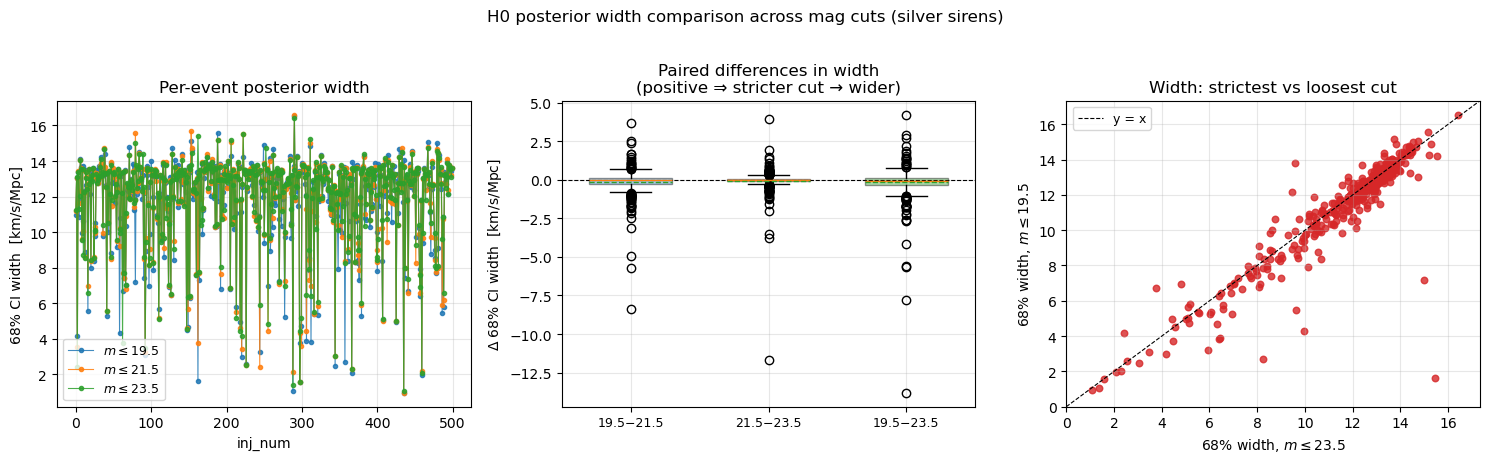

,inj_num,z,DL,w68_19.5,std_19.5,med_19.5,w68_21.5,std_21.5,med_21.5,w68_23.5,std_23.5,med_23.5
0,0,0.441805,2518.247159,10.987514,4.947387,68.177596,11.172360,5.022961,67.791962,11.234192,5.041341,67.792549
1,1,0.206377,1047.522363,13.052501,5.609965,71.490120,13.071317,5.613577,71.491089,13.114142,5.628953,71.506606
2,2,0.154485,760.351415,4.164958,2.989231,66.980586,3.534412,3.032066,66.979117,2.425289,2.397744,66.890822
3,3,0.285799,1514.599959,13.392819,5.713280,69.744177,13.414559,5.718126,69.990922,13.400928,5.713615,70.160507
4,4,0.226393,1162.184325,10.848980,5.070036,74.394715,11.612163,5.251450,73.994336,11.319556,5.177041,74.177514
5,5,0.296242,1578.347647,11.797886,5.228357,68.633734,12.312245,5.376745,68.934968,12.021867,5.291895,68.967208
6,6,0.302539,1617.046210,14.138694,5.975854,68.774063,14.054841,5.942590,68.663603,14.074084,5.952930,68.617979
7,7,0.221540,1134.194532,13.667661,5.804806,69.606348,13.613139,5.789364,69.239919,13.555387,5.772736,69.052880
8,8,0.138942,677.276594,9.934178,4.574361,67.749610,9.613208,4.471146,67.874964,9.572472,4.470978,68.211908
9,9,0.329142,1782.569754,13.704172,5.860582,66.916015,13.475053,5.784122,67.413185,13.543142,5.804826,67.342878


In [18]:
from scipy import stats as sps

def posterior_width(H0_grid, post, level=0.68):
    """Return (CI width, std, median) for a 1-D posterior on H0_grid.
    Returns NaNs if the posterior is empty / un-normalisable."""
    if not np.any(post > 0) or not np.all(np.isfinite(post)):
        return np.nan, np.nan, np.nan
    dH   = np.diff(H0_grid)
    norm = np.sum(0.5 * (post[:-1] + post[1:]) * dH)
    if norm <= 0 or not np.isfinite(norm):
        return np.nan, np.nan, np.nan
    p    = post / norm
    cdf  = np.concatenate([[0.0], np.cumsum(0.5 * (p[:-1] + p[1:]) * dH)])
    cdf /= cdf[-1]
    tail = (1 - level) / 2
    lo   = np.interp(tail,     cdf, H0_grid)
    hi   = np.interp(1 - tail, cdf, H0_grid)
    med  = np.interp(0.5,      cdf, H0_grid)
    mean = np.sum(0.5 * ((p * H0_grid)[:-1] + (p * H0_grid)[1:]) * dH)
    var  = np.sum(0.5 * ((p * (H0_grid - mean)**2)[:-1]
                       + (p * (H0_grid - mean)**2)[1:]) * dH)
    return hi - lo, np.sqrt(max(var, 0.0)), med

# ── Build per-event width table ──────────────────────────────────────────────
width_rows = []
for ekey in all_event_keys:
    inj_n = int(ekey.split('_')[1])
    row   = {'inj_num': inj_n,
             'z':  event_meta.get(ekey, {}).get(f'z_{APP_MAG_LIMITS[0]}',  np.nan),
             'DL': event_meta.get(ekey, {}).get(f'DL_{APP_MAG_LIMITS[0]}', np.nan)}
    for m in APP_MAG_LIMITS:
        if m in npz_data and ekey in npz_data[m]:
            w68, sd, med = posterior_width(H0_GRID, npz_data[m][ekey], 0.68)
        else:
            w68, sd, med = np.nan, np.nan, np.nan
        row[f'w68_{m}'] = w68
        row[f'std_{m}'] = sd
        row[f'med_{m}'] = med
    width_rows.append(row)

widths = pd.DataFrame(width_rows)

# ── Summary statistics across events ─────────────────────────────────────────
summary_stats = []
for m in APP_MAG_LIMITS:
    w = widths[f'w68_{m}'].dropna()
    s = widths[f'std_{m}'].dropna()
    summary_stats.append({
        'mag_limit':  m,
        'n_events':   len(w),
        'w68_mean':   w.mean(),
        'w68_median': w.median(),
        'w68_std':    w.std(),
        'std_mean':   s.mean(),
        'std_median': s.median(),
    })
summary_widths = pd.DataFrame(summary_stats)
print("Per-cut posterior-width summary:")
print(summary_widths.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── Paired statistical tests (per event) ─────────────────────────────────────
print("\nPaired tests on 68% CI width (Δ = w68[stricter] − w68[looser]):")
print("Positive Δ ⇒ stricter (smaller m_lim) cut gives wider posterior.\n")

def paired_tests(a, b, label_a, label_b):
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    diff = a - b
    if len(diff) < 2:
        print(f"  {label_a} vs {label_b}: too few paired events"); return
    t_stat, t_p = sps.ttest_rel(a, b)
    try:
        w_stat, w_p = sps.wilcoxon(a, b, zero_method='wilcox')
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    print(f"  {label_a} vs {label_b}  (n={len(diff)}):")
    print(f"     mean Δ = {diff.mean():+.3f}   median Δ = {np.median(diff):+.3f}   "
          f"std Δ = {diff.std():.3f}")
    print(f"     paired t-test : t={t_stat:+.3f},  p={t_p:.3g}")
    print(f"     Wilcoxon      : W={w_stat:.1f},   p={w_p:.3g}")

w19, w21, w23 = (widths[f'w68_{m}'].values for m in APP_MAG_LIMITS)
paired_tests(w19, w21, f"m≤{APP_MAG_LIMITS[0]}", f"m≤{APP_MAG_LIMITS[1]}")
paired_tests(w21, w23, f"m≤{APP_MAG_LIMITS[1]}", f"m≤{APP_MAG_LIMITS[2]}")
paired_tests(w19, w23, f"m≤{APP_MAG_LIMITS[0]}", f"m≤{APP_MAG_LIMITS[2]}")

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) per-event 68% width vs event index
ax = axes[0]
for m, color in zip(APP_MAG_LIMITS, COLORS):
    ax.plot(widths['inj_num'], widths[f'w68_{m}'], 'o-', color=color, ms=3, lw=0.8,
            alpha=0.85, label=rf"$m\leq{m}$")
ax.set_xlabel("inj_num"); ax.set_ylabel("68% CI width  [km/s/Mpc]")
ax.set_title("Per-event posterior width"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (b) paired differences in 68% width
ax = axes[1]
pairs = [
    (w19, w21, f"{APP_MAG_LIMITS[0]}−{APP_MAG_LIMITS[1]}", COLORS[0]),
    (w21, w23, f"{APP_MAG_LIMITS[1]}−{APP_MAG_LIMITS[2]}", COLORS[1]),
    (w19, w23, f"{APP_MAG_LIMITS[0]}−{APP_MAG_LIMITS[2]}", COLORS[2]),
]
positions, data, labels, colors_ = [], [], [], []
for i, (a, b, lbl, c) in enumerate(pairs):
    d = (a - b); d = d[np.isfinite(d)]
    data.append(d); positions.append(i); labels.append(lbl); colors_.append(c)
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=True)
for patch, c in zip(bp['boxes'], colors_):
    patch.set_facecolor(c); patch.set_alpha(0.4)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(r"$\Delta$ 68% CI width  [km/s/Mpc]")
ax.set_title("Paired differences in width\n(positive ⇒ stricter cut → wider)")
ax.grid(alpha=0.3)

# (c) width(strictest) vs width(loosest)
ax = axes[2]
mask = np.isfinite(w19) & np.isfinite(w23)
ax.scatter(w23[mask], w19[mask], s=22, alpha=0.8, color='C3')
lim = [0, max(np.nanmax(w19[mask]), np.nanmax(w23[mask])) * 1.05]
ax.plot(lim, lim, 'k--', lw=0.8, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(rf"68% width, $m\leq{APP_MAG_LIMITS[2]}$")
ax.set_ylabel(rf"68% width, $m\leq{APP_MAG_LIMITS[0]}$")
ax.set_title("Width: strictest vs loosest cut")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle(f"H0 posterior width comparison across mag cuts ({SIREN_TYPE} sirens)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

display(widths.head(15))

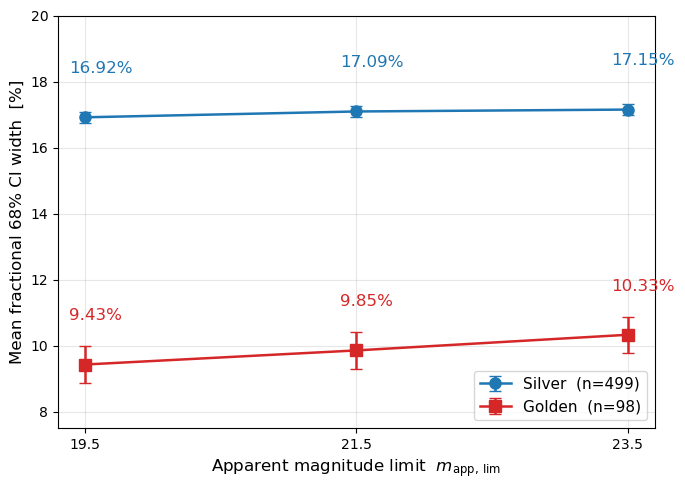


[silver]  n=499
  Mean   frac w68 [%]: {19.5: np.float64(16.916), 21.5: np.float64(17.092), 23.5: np.float64(17.15)}

[golden]  n=98
  Mean   frac w68 [%]: {19.5: np.float64(9.427), 21.5: np.float64(9.854), 23.5: np.float64(10.328)}


In [10]:
# ── Growth of mean fractional 68% CI width vs. magnitude limit ───────────────
# Overlays silver and golden so the two populations can be compared on one plot.
# Per-event w68 / med values come from the widths_by_type table built here, which
# reuses the posterior_width() helper defined in the previous cell.
mlim_arr = np.array(APP_MAG_LIMITS, dtype=float)

def _build_widths_table(npz_by_m, ekeys):
    rows = []
    for ekey in ekeys:
        row = {"inj_num": int(ekey.split("_")[1])}
        for m in APP_MAG_LIMITS:
            if m in npz_by_m and ekey in npz_by_m[m]:
                w68, sd, med = posterior_width(H0_GRID, npz_by_m[m][ekey], 0.68)
            else:
                w68, sd, med = np.nan, np.nan, np.nan
            row[f"w68_{m}"] = w68
            row[f"std_{m}"] = sd
            row[f"med_{m}"] = med
        rows.append(row)
    return pd.DataFrame(rows)

widths_by_type = {
    s: _build_widths_table(npz_data_all[s], all_event_keys_all[s])
    for s in SIREN_TYPES
}

# Fractional width per event: w68 / median(H0_posterior), in %, per siren type.
frac_widths_by_type = {
    s: {
        m: (widths_by_type[s][f"w68_{m}"] / widths_by_type[s][f"med_{m}"] * 100)
              .replace([np.inf, -np.inf], np.nan)
        for m in APP_MAG_LIMITS
    }
    for s in SIREN_TYPES
}

# Aggregate per-type stats.
agg = {}
for s in SIREN_TYPES:
    fw = frac_widths_by_type[s]
    mean_fw   = np.array([fw[m].dropna().mean()   for m in APP_MAG_LIMITS])
    std_fw    = np.array([fw[m].dropna().std()    for m in APP_MAG_LIMITS])
    n_eff     = np.array([fw[m].dropna().size     for m in APP_MAG_LIMITS])
    sem_fw    = std_fw / np.sqrt(np.maximum(n_eff, 1))
    agg[s] = dict(mean=mean_fw, sem=sem_fw, n=n_eff)

# ── Plot: mean fractional width growth, both siren types overlaid ───────────
fig, ax = plt.subplots(figsize=(7, 5))

for s in SIREN_TYPES:
    color  = SIREN_COLORS[s]
    marker = SIREN_MARKERS[s]
    a      = agg[s]
    ax.errorbar(mlim_arr, a["mean"], yerr=a["sem"],
                fmt=marker + "-", color=color, lw=1.8, ms=8, capsize=4,
                label=f"{s.capitalize()}  (n={a['n'][0]})")
    for x, y in zip(mlim_arr, a["mean"]):
        ax.annotate(f"{y:.2f}%", (x-0.2, y+1), textcoords="offset points",
                    xytext=(8, 8), fontsize=12, color=color)
ax.set_xticks(mlim_arr)
ax.set_xlabel(r"Apparent magnitude limit  $m_\mathrm{app,\,lim}$", fontsize=12)
ax.set_ylabel(r"Mean fractional 68% CI width  [%]", fontsize=12)
ax.set_ylim(7.5,20)
ax.legend(fontsize=11, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(STUDY_ROOT, "fracwidth_growth_vs_mlim_silver_vs_golden.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# ── Numeric summary ──────────────────────────────────────────────────────────
for s in SIREN_TYPES:
    print(f"\n[{s}]  n={agg[s]['n'][0]}")
    print("  Mean   frac w68 [%]:", dict(zip(APP_MAG_LIMITS, np.round(agg[s]["mean"],   3))))


## 8  Joint-posterior width vs. magnitude cut — silver vs golden

For each siren type, combine $N$ events into a joint $H_0$ posterior under each
magnitude cut, and trace how the joint 68% CI width responds to $N$ and to the
cut. Silver and golden are overlaid on the same axes so the two populations can
be compared directly. Bootstrapped subsets at each $N$ give the uncertainty bands.


In [20]:
# ── Joint-posterior fractional width vs. N-events subset, silver vs golden ──
# For each siren type we build the per-cut log-likelihood stack over the events
# that exist in ALL three cuts of that type, then draw bootstrap subsets of size N.

def stable_logpost(post):
    p = np.where(post > 0, post, np.finfo(float).tiny)
    return np.log(p)

def joint_frac_width(log_event_array, idx, H0_grid, level=0.68):
    log_joint = log_event_array[idx].sum(axis=0)
    log_joint -= log_joint.max()
    joint = np.exp(log_joint)
    dH    = np.diff(H0_grid)
    norm  = np.sum(0.5 * (joint[:-1] + joint[1:]) * dH)
    if norm <= 0 or not np.isfinite(norm):
        return np.nan
    p   = joint / norm
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (p[:-1] + p[1:]) * dH)])
    cdf /= cdf[-1]
    tail = (1 - level) / 2
    lo  = np.interp(tail,     cdf, H0_grid)
    hi  = np.interp(1 - tail, cdf, H0_grid)
    med = np.interp(0.5,      cdf, H0_grid)
    if med <= 0 or not np.isfinite(med):
        return np.nan
    return float((hi - lo) / med)

# Build per-type log-likelihood stacks over events common to all three cuts.
common_keys_by_type = {}
logL_by_type        = {}
for s in SIREN_TYPES:
    common = sorted(
        set.intersection(*[set(k for k in npz_data_all[s][m].files if k.startswith("event_"))
                           for m in APP_MAG_LIMITS]),
        key=lambda k: int(k.split("_")[1])
    )
    common_keys_by_type[s] = common
    logL_by_type[s] = {
        m: np.stack([stable_logpost(npz_data_all[s][m][k]) for k in common])
        for m in APP_MAG_LIMITS
    }
    print(f"  {s:<6s}: {len(common)} events common to all three cuts")

# Per-type subset-size grids. Bootstrapping is capped per siren type:
#   golden ≤ 50, silver ≤ 100.
SUBSET_SIZES_FULL = [10, 15, 25, 50, 100, 200, 500]
SUBSET_CAP = {"silver": 100, "golden": 50}
SUBSET_SIZES_BY_TYPE = {
    s: [N for N in SUBSET_SIZES_FULL if N <= SUBSET_CAP[s]]
    for s in SIREN_TYPES
}
for s in SIREN_TYPES:
    print(f"  {s:<6s} subset sizes: {SUBSET_SIZES_BY_TYPE[s]}")

N_BOOT = 400
rng    = np.random.default_rng(42)

# joint_results[siren_type][m][N] = array of fractional widths
joint_results = {s: {m: {} for m in APP_MAG_LIMITS} for s in SIREN_TYPES}
for s in SIREN_TYPES:
    N_tot = len(common_keys_by_type[s])
    for N in SUBSET_SIZES_BY_TYPE[s]:
        N_eff = min(N, N_tot)
        if N_eff >= N_tot:
            idx_list = [np.arange(N_tot)]
        else:
            idx_list = [rng.choice(N_tot, size=N_eff, replace=False) for _ in range(N_BOOT)]
        for m in APP_MAG_LIMITS:
            joint_results[s][m][N] = np.array(
                [joint_frac_width(logL_by_type[s][m], idx, H0_GRID) for idx in idx_list]
            )

m_deep = APP_MAG_LIMITS[-1]


  silver: 499 events common to all three cuts
  golden: 98 events common to all three cuts
  silver subset sizes: [10, 15, 25, 50, 100]
  golden subset sizes: [10, 15, 25, 50]


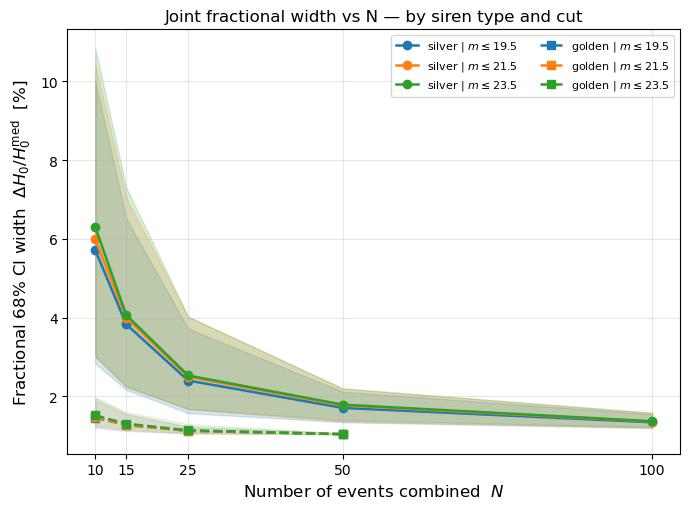

In [21]:
# ── Plot 1: joint fractional width vs N — by siren type and cut ─────────────
fig, ax = plt.subplots(figsize=(7, 5.2))
for s in SIREN_TYPES:
    ls     = SIREN_LINESTYLE[s]
    marker = SIREN_MARKERS[s]
    Ns     = SUBSET_SIZES_BY_TYPE[s]
    for m, color in zip(APP_MAG_LIMITS, COLORS):
        medians = np.array([np.nanmedian(joint_results[s][m][N]) for N in Ns])
        los     = np.array([np.nanquantile(joint_results[s][m][N], 0.16) for N in Ns])
        his     = np.array([np.nanquantile(joint_results[s][m][N], 0.84) for N in Ns])
        ax.fill_between(Ns, los * 100, his * 100,
                        color=color, alpha=0.10 if s == "golden" else 0.18)
        ax.plot(Ns, medians * 100, ls + marker,
                color=color, lw=1.8, ms=6,
                label=f"{s} | $m\\leq{m}$")
ax.set_xlabel("Number of events combined  $N$", fontsize=12)
ax.set_ylabel(r"Fractional 68% CI width  $\Delta H_0 / H_0^{\rm med}$  [%]", fontsize=12)
xticks_all = sorted(set().union(*SUBSET_SIZES_BY_TYPE.values()))
ax.set_xticks(xticks_all); ax.set_xticklabels([str(n) for n in xticks_all])
ax.set_title("Joint fractional width vs N — by siren type and cut")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(STUDY_ROOT, "joint_fracwidth_vs_N_by_type_and_cut.png"),
            dpi=200, bbox_inches="tight")
plt.show()


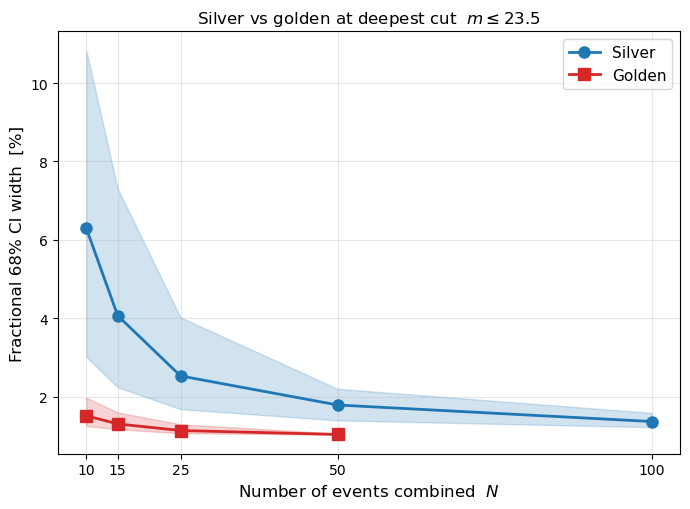

In [22]:
# ── Plot 2: silver vs golden at deepest cut ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.2))
for s in SIREN_TYPES:
    color  = SIREN_COLORS[s]
    marker = SIREN_MARKERS[s]
    Ns     = SUBSET_SIZES_BY_TYPE[s]
    medians = np.array([np.nanmedian(joint_results[s][m_deep][N]) for N in Ns])
    los     = np.array([np.nanquantile(joint_results[s][m_deep][N], 0.16) for N in Ns])
    his     = np.array([np.nanquantile(joint_results[s][m_deep][N], 0.84) for N in Ns])
    ax.fill_between(Ns, los * 100, his * 100, color=color, alpha=0.2)
    ax.plot(Ns, medians * 100, marker + "-", color=color, lw=2.0, ms=8,
            label=f"{s.capitalize()}")
ax.set_xlabel("Number of events combined  $N$", fontsize=12)
ax.set_ylabel(r"Fractional 68% CI width  [%]", fontsize=12)
xticks_all = sorted(set().union(*SUBSET_SIZES_BY_TYPE.values()))
ax.set_xticks(xticks_all); ax.set_xticklabels([str(n) for n in xticks_all])
ax.set_title(rf"Silver vs golden at deepest cut  $m\leq{m_deep}$")
ax.legend(fontsize=11, loc="upper right")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(os.path.join(STUDY_ROOT, "joint_fracwidth_vs_N_silver_vs_golden_deepest.png"),
            dpi=200, bbox_inches="tight")
plt.show()


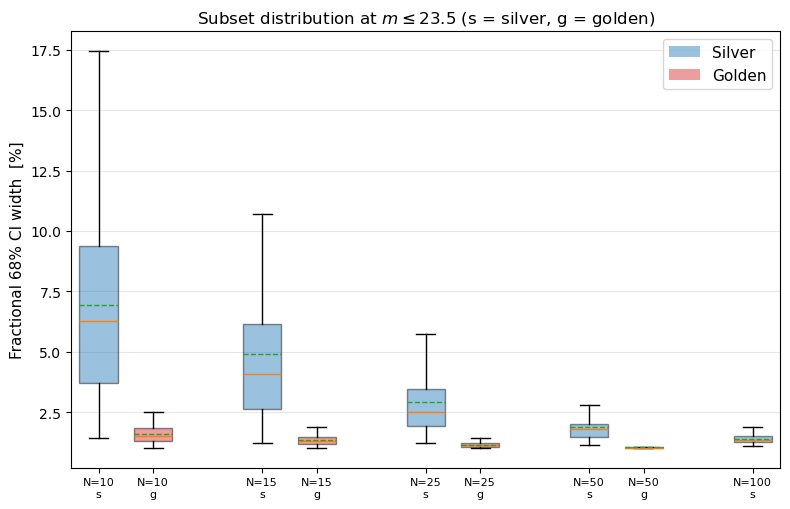


Joint fractional 68% CI width [%] across bootstrap subsets:
 siren   N  mag_limit  median_frac_w68_%  mean_frac_w68_%   16%    84%
silver  10     19.500              5.717            6.333 2.837 10.005
silver  10     21.500              5.988            6.733 3.012 10.426
silver  10     23.500              6.298            6.953 3.015 10.828
silver  15     19.500              3.831            4.449 2.168  6.520
silver  15     21.500              3.998            4.731 2.255  7.040
silver  15     23.500              4.069            4.900 2.245  7.307
silver  25     19.500              2.404            2.723 1.578  3.723
silver  25     21.500              2.499            2.886 1.675  4.029
silver  25     23.500              2.532            2.919 1.685  4.024
silver  50     19.500              1.710            1.796 1.347  2.121
silver  50     21.500              1.770            1.864 1.364  2.201
silver  50     23.500              1.791            1.880 1.399  2.204
silver 100     1

In [23]:
# ── Plot 3: subset distribution box plot at deepest cut ─────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 5.2))
positions = []
data, colors_, labels = [], [], []
pos = 0
# Union of subset sizes across types, but each siren type only contributes the
# sizes that are within its own cap. Box plot includes a per-type box only when
# that N is in the type's allowed list and is less than the type's event total.
all_N = sorted(set().union(*SUBSET_SIZES_BY_TYPE.values()))
for N in all_N:
    added_any = False
    for s in SIREN_TYPES:
        if N not in SUBSET_SIZES_BY_TYPE[s]:
            continue
        if N >= len(common_keys_by_type[s]):
            continue
        data.append(joint_results[s][m_deep][N] * 100)
        positions.append(pos)
        colors_.append(SIREN_COLORS[s])
        labels.append(f"N={N}\n{s[0]}")
        pos += 1
        added_any = True
    if added_any:
        pos += 1  # gap

bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True,
                showfliers=False, showmeans=True, meanline=True)
for patch, c in zip(bp["boxes"], colors_):
    patch.set_facecolor(c); patch.set_alpha(0.45)
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel(r"Fractional 68% CI width  [%]", fontsize=11)
ax.set_title(rf"Subset distribution at $m\leq{m_deep}$ (s = silver, g = golden)")
ax.grid(alpha=0.3, axis="y")
legend_handles = [Patch(facecolor=SIREN_COLORS[s], alpha=0.45, label=s.capitalize())
                  for s in SIREN_TYPES]
ax.legend(handles=legend_handles, fontsize=11, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(STUDY_ROOT, "joint_fracwidth_subset_distribution_deepest.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# ── Print combined table ────────────────────────────────────────────────────
rows = []
for s in SIREN_TYPES:
    for N in SUBSET_SIZES_BY_TYPE[s]:
        for m in APP_MAG_LIMITS:
            w = joint_results[s][m][N] * 100
            rows.append({
                "siren": s, "N": N, "mag_limit": m,
                "median_frac_w68_%": np.nanmedian(w),
                "mean_frac_w68_%":   np.nanmean(w),
                "16%":               np.nanquantile(w, 0.16),
                "84%":               np.nanquantile(w, 0.84),
            })
joint_table = pd.DataFrame(rows)
print("\nJoint fractional 68% CI width [%] across bootstrap subsets:")
print(joint_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


## 9  Bias of joint $H_0$ posterior median vs. $N$ — silver vs golden

For each siren type and magnitude cut, combine $N$ events into a joint $H_0$
posterior and record the **median offset from the injected truth**
$\Delta H_0 = H_0^{\rm med} - H_0^{\rm true}$ (with $H_0^{\rm true}=67.5$).
We bootstrap subsets of size $N$ to characterise the realisation-to-realisation
spread. A persistent non-zero $\Delta H_0$ that does not shrink with $N$ is a
systematic bias; a spread that shrinks $\propto 1/\sqrt{N}$ is consistent with
statistical noise.


In [33]:
# ── Bias of joint H0 median vs N — bootstrap subsets ────────────────────────
# Reuses logL_by_type, common_keys_by_type, SUBSET_SIZES_BY_TYPE from section 8.

def joint_median(log_event_array, idx, H0_grid):
    log_joint = log_event_array[idx].sum(axis=0)
    log_joint -= log_joint.max()
    joint = np.exp(log_joint)
    dH    = np.diff(H0_grid)
    norm  = np.sum(0.5 * (joint[:-1] + joint[1:]) * dH)
    if norm <= 0 or not np.isfinite(norm):
        return np.nan
    p   = joint / norm
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (p[:-1] + p[1:]) * dH)])
    cdf /= cdf[-1]
    return float(np.interp(0.5, cdf, H0_grid))

rng_bias = np.random.default_rng(123)
N_BOOT_BIAS = 400

# bias_results[siren_type][m][N] = array of (median - H0_true) per bootstrap draw
bias_results = {s: {m: {} for m in APP_MAG_LIMITS} for s in SIREN_TYPES}
for s in SIREN_TYPES:
    N_tot = len(common_keys_by_type[s])
    for N in SUBSET_SIZES_BY_TYPE[s]:
        N_eff = min(N, N_tot)
        if N_eff >= N_tot:
            idx_list = [np.arange(N_tot)]
        else:
            idx_list = [rng_bias.choice(N_tot, size=N_eff, replace=False)
                        for _ in range(N_BOOT_BIAS)]
        for m in APP_MAG_LIMITS:
            meds = np.array([joint_median(logL_by_type[s][m], idx, H0_GRID)
                             for idx in idx_list])
            bias_results[s][m][N] = meds - H0_TRUE


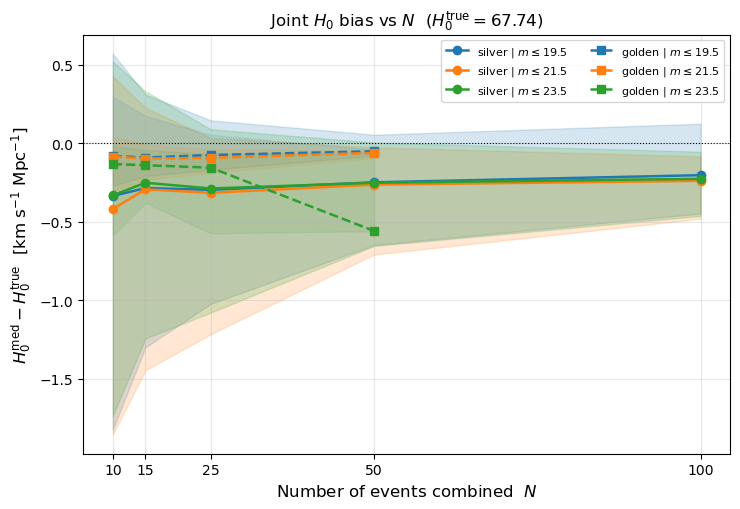

Saved: maglim_study_silver/joint_bias_vs_N_by_type_and_cut.png


In [34]:
# ── Plot 1: bias vs N — by siren type and cut ───────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for s in SIREN_TYPES:
    ls     = SIREN_LINESTYLE[s]
    marker = SIREN_MARKERS[s]
    Ns     = SUBSET_SIZES_BY_TYPE[s]
    for m, color in zip(APP_MAG_LIMITS, COLORS):
        medians = np.array([np.nanmedian(bias_results[s][m][N]) for N in Ns])
        los     = np.array([np.nanquantile(bias_results[s][m][N], 0.16) for N in Ns])
        his     = np.array([np.nanquantile(bias_results[s][m][N], 0.84) for N in Ns])
        ax.fill_between(Ns, los, his,
                        color=color, alpha=0.10 if s == "golden" else 0.18)
        ax.plot(Ns, medians, ls + marker,
                color=color, lw=1.8, ms=6,
                label=f"{s} | $m\\leq{m}$")
ax.axhline(0.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("Number of events combined  $N$", fontsize=12)
ax.set_ylabel(r"$H_0^{\rm med} - H_0^{\rm true}$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=12)
xticks_all = sorted(set().union(*SUBSET_SIZES_BY_TYPE.values()))
ax.set_xticks(xticks_all); ax.set_xticklabels([str(n) for n in xticks_all])
ax.set_title(rf"Joint $H_0$ bias vs $N$  ($H_0^{{\rm true}}={H0_TRUE:g}$)")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8, ncol=2, loc="best")
plt.tight_layout()
out_path = os.path.join(STUDY_ROOT, "joint_bias_vs_N_by_type_and_cut.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


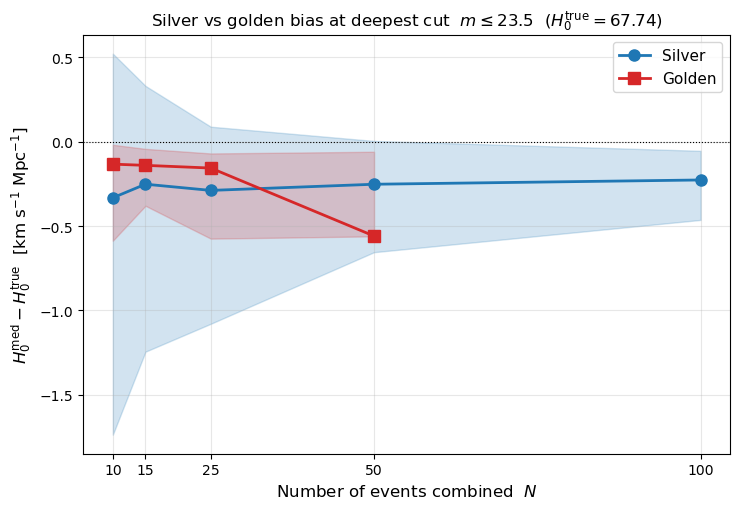

Saved: maglim_study_silver/joint_bias_vs_N_silver_vs_golden_deepest.png

Joint H0 bias  (median - H0_true,  H0_true=67.74)  across bootstrap subsets:
 siren   N  mag_limit  median_bias  mean_bias  std_bias    16%    84%
silver  10     19.500       -0.336     -0.534     1.650 -1.825  0.570
silver  10     21.500       -0.420     -0.585     1.618 -1.857  0.426
silver  10     23.500       -0.333     -0.455     1.590 -1.736  0.521
silver  15     19.500       -0.286     -0.409     1.241 -1.300  0.309
silver  15     21.500       -0.294     -0.546     1.264 -1.447  0.224
silver  15     23.500       -0.252     -0.413     1.342 -1.244  0.330
silver  25     19.500       -0.297     -0.427     0.980 -1.024  0.145
silver  25     21.500       -0.317     -0.553     0.951 -1.217  0.033
silver  25     23.500       -0.289     -0.475     0.904 -1.079  0.088
silver  50     19.500       -0.250     -0.266     0.511 -0.649  0.053
silver  50     21.500       -0.264     -0.363     0.435 -0.710 -0.027
silver  50

In [35]:
# ── Plot 2: silver vs golden bias at the deepest cut ───────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for s in SIREN_TYPES:
    color  = SIREN_COLORS[s]
    marker = SIREN_MARKERS[s]
    Ns     = SUBSET_SIZES_BY_TYPE[s]
    medians = np.array([np.nanmedian(bias_results[s][m_deep][N]) for N in Ns])
    los     = np.array([np.nanquantile(bias_results[s][m_deep][N], 0.16) for N in Ns])
    his     = np.array([np.nanquantile(bias_results[s][m_deep][N], 0.84) for N in Ns])
    ax.fill_between(Ns, los, his, color=color, alpha=0.2)
    ax.plot(Ns, medians, marker + "-", color=color, lw=2.0, ms=8,
            label=f"{s.capitalize()}")
ax.axhline(0.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("Number of events combined  $N$", fontsize=12)
ax.set_ylabel(r"$H_0^{\rm med} - H_0^{\rm true}$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=12)
xticks_all = sorted(set().union(*SUBSET_SIZES_BY_TYPE.values()))
ax.set_xticks(xticks_all); ax.set_xticklabels([str(n) for n in xticks_all])
ax.set_title(rf"Silver vs golden bias at deepest cut  $m\leq{m_deep}$  ($H_0^{{\rm true}}={H0_TRUE:g}$)")
ax.legend(fontsize=11, loc="best")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
out_path = os.path.join(STUDY_ROOT, "joint_bias_vs_N_silver_vs_golden_deepest.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# ── Bias summary table ──────────────────────────────────────────────────────
rows = []
for s in SIREN_TYPES:
    for N in SUBSET_SIZES_BY_TYPE[s]:
        for m in APP_MAG_LIMITS:
            b = bias_results[s][m][N]
            rows.append({
                "siren": s, "N": N, "mag_limit": m,
                "median_bias": np.nanmedian(b),
                "mean_bias":   np.nanmean(b),
                "std_bias":    np.nanstd(b),
                "16%":         np.nanquantile(b, 0.16),
                "84%":         np.nanquantile(b, 0.84),
            })
bias_table = pd.DataFrame(rows)
print(f"\nJoint H0 bias  (median - H0_true,  H0_true={H0_TRUE:g})  across bootstrap subsets:")
print(bias_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
